# Backbone Experiment: Mel Spectrogram + PANN Cnn14 (AudioSet-pretrained)

Fine-tunes [PANN's Cnn14](https://github.com/qiuqiangkong/audioset_tagging_cnn) — a CNN pretrained on AudioSet (2M+ clips, 527-class general audio classification) — on PSG-Audio for binary sleep apnea detection. The model performs its own log-Mel feature extraction internally; we feed it raw 16 kHz audio (resampled on the GPU to 32 kHz to match the pretrained sample rate).

## Objectives
- Load and preprocess PSG-Audio segments
- Perform a subject-wise stratified train/val/test split (no subject leakage; balanced apnea ratios; **identical test set to the other backbone notebooks**)
- Fine-tune an audio-pretrained CNN end-to-end for binary apnea vs non-apnea classification
- Evaluate with accuracy, macro F1, confusion matrix, and per apnea-type recall
- Persist the best checkpoint, training curves, and a results JSON

## Companion notebooks (same data, splits, loss; only the backbone changes)
- [`mel_cnn.ipynb`](../Mel/mel_cnn.ipynb) — ImageNet-pretrained ResNet18 (the headline backbone result)
- [`mel_ast.ipynb`](../Mel/mel_ast.ipynb) — AudioSet-pretrained AST transformer (abandoned: didn't fit on the laptop GPU)
- [`raw_waveform_1dcnn.ipynb`](../Raw_waveform_1dcnn/raw_waveform_1dcnn.ipynb) — no feature engineering, small 1D CNN trained from scratch

## Why PANN Cnn14 specifically
- **Pretrained on audio** (AudioSet, 2M+ clips) — the early conv filters already understand spectrogram structure, unlike `mel_cnn.ipynb`'s ImageNet baseline
- **Fully convolutional** — activation memory scales linearly with input length. This is the key reason PANN fits on the laptop GPU where the similarly-sized [AST transformer](../Mel/mel_ast.ipynb) (~85M params, 1024-frame quadratic attention) does not.
- **Standard public weights** (`Cnn14_mAP=0.431.pth` on Zenodo, mAP=0.431 on AudioSet eval) — fully reproducible

Section 9 (Findings) reports the headline metrics and discusses how PANN compares against the ImageNet-pretrained baseline.

## Experiment summary

A high-level snapshot of the recipe — full justifications appear in the relevant sections below.

| Component | Choice |
|---|---|
| **Input** | 10-second 16 kHz audio segments (160,000 samples) |
| **Resampling** | 16 kHz → 32 kHz on GPU inside `forward()` (matches Cnn14's pretraining sample rate) |
| **Feature** | Log-Mel computed inside Cnn14: **n_mels=64**, n_fft=1024, hop=320, f_min=50, f_max=14000 (Cnn14 pretraining config — fixed, do not change) |
| **Backbone** | PANN Cnn14 (AudioSet-pretrained, ~79.7M trainable params) |
| **Classifier head** | `Dropout(0.5)` + `Linear(2048, 2)` replacing Cnn14's 527-way AudioSet head |
| **Loss** | Focal loss (γ=2.0) with class-weighted α |
| **Optimizer** | AdamW, LR=5e-5, weight decay=1e-3 |
| **Scheduler** | `ReduceLROnPlateau` on val macro-F1, patience=2, factor=0.5 |
| **Mixed precision** | bf16 autocast on GPU (Tensor Cores) |
| **Regularization** | Dropout 0.5 in head, gradient clipping (max norm 1.0) |
| **Subject-wise split** | Stratified by per-subject apnea fraction (quartiles); 70/15/15, seed=42 — *identical test set across all backbone notebooks* |
| **Class imbalance** | Focal-loss α weights computed from training split only |
| **Schedule** | Up to 10 epochs, early stop after 4 stagnant epochs on val macro-F1 |
| **Selection** | Best-by-val-F1 checkpoint reloaded for test evaluation |
| **Pretrained checkpoint** | `Cnn14_mAP=0.431.pth` (~330 MB, downloaded from Zenodo) |

## 1. Setup

Imports, device, and reproducibility seeds. Requires `panns_inference` — install with `pip install panns_inference` if missing. First-time run downloads ~330 MB of pretrained weights to `~/panns_data/`.

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchaudio

from panns_inference.models import Cnn14

# Shared dataset class (importable so DataLoader workers can pickle it on Windows)
from audio_datasets import RawWaveformDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Configuration

Paths and hyperparameters. Notable differences from `mel_ast.ipynb`:
- `BATCH_SIZE=32` — Cnn14 has linear-scaling activations; doesn't need AST's tiny batch
- `LEARNING_RATE=5e-5` — between mel_cnn's 1e-4 (image-pretrained, less domain match) and mel_ast's 1e-5 (transformer fine-tuning sensitivity)
- `NUM_EPOCHS=10` — pretrained backbone, expect convergence by epoch 5-7

In [3]:
# === Dataset ===
DATASET_ROOT = Path(r"C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset")
PSG_DIR      = DATASET_ROOT / "PSG-AUDIO" / "APNEA_EDF"
AP_TYPES_DIR = DATASET_ROOT / "APNEA_types"

# === Artifact output ===
PROJECT_ROOT = Path.cwd().resolve().parents[4]
ARTIFACT_DIR   = PROJECT_ROOT / "experiments" / "artifacts" / "audio" / "feature_representation" / "mel_pann"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
RESULTS_DIR    = ARTIFACT_DIR / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# === Audio ===
SOURCE_SR = 16000   # our PSG-Audio data
PANN_SR   = 32000   # what Cnn14 pretrained weights expect

# === Apnea type mapping ===
APNEA_TYPE_NAMES = {0: "non-apnea", 1: "OSA", 2: "CSA", 3: "Mixed/Hypopnea", 4: "Other"}

# === PANN params (match Cnn14 pretraining config — do not change) ===
PANN_WINDOW_SIZE = 1024
PANN_HOP_SIZE    = 320
PANN_MEL_BINS    = 64
PANN_FMIN        = 50
PANN_FMAX        = 14000
PANN_AUDIOSET_CLASSES = 527
# Path where panns_inference downloads the Cnn14 checkpoint on first use
PANN_CHECKPOINT_PATH = Path.home() / "panns_data" / "Cnn14_mAP=0.431.pth"

# === DataLoader ===
BATCH_SIZE   = 32
NUM_WORKERS  = 4
WAVE_CACHE_SIZE = 4   # smaller than mel_ast — raw audio is bigger; avoid worker RAM blowup

# === Loss ===
FOCAL_GAMMA = 2.0

# === Training ===
SEED                = 42
NUM_EPOCHS          = 10
LEARNING_RATE       = 5e-5
WEIGHT_DECAY        = 1e-3
DROPOUT             = 0.5
GRAD_CLIP           = 1.0
EARLY_STOP_PATIENCE = 4
LR_SCHED_PATIENCE   = 2
NUM_CLASSES         = 2
CLASS_NAMES         = ["non-apnea", "apnea"]

# === Reproducibility ===
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print("Artifact dir:", ARTIFACT_DIR)
print("PANN checkpoint path:", PANN_CHECKPOINT_PATH)
print("PSG dir exists:", PSG_DIR.exists())

Artifact dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\mel_pann
PANN checkpoint path: C:\Users\arshi\panns_data\Cnn14_mAP=0.431.pth
PSG dir exists: True


## 3. Data preparation

### 3.1 Build records DataFrame

Same flat-record layout as the other backbone notebooks — one row per segment.

In [4]:
def build_records(psg_dir, ap_types_dir):
    """Build (subject_id, segment_idx, label, apnea_type, file_type) records
    from npy headers without loading audio payloads."""
    records = []
    subjects = sorted(os.listdir(psg_dir))

    for subj in subjects:
        subj_path  = psg_dir / subj
        ap_file    = subj_path / f"{subj}_ap.npy"
        nap_file   = subj_path / f"{subj}_nap.npy"
        types_file = ap_types_dir / f"{subj}_ap_types.npy"

        if ap_file.exists():
            ap_types = np.load(types_file, allow_pickle=False) if types_file.exists() else None
            ap_mm = np.load(ap_file, mmap_mode="r")
            n_ap = ap_mm.shape[0]
            del ap_mm
            for i in range(n_ap):
                records.append({
                    "subject_id": subj, "segment_idx": i, "label": 1,
                    "apnea_type": int(ap_types[i]) if ap_types is not None else -1,
                    "file_type": "ap",
                })

        if not nap_file.exists():
            continue
        nap_mm = np.load(nap_file, mmap_mode="r")
        n_nap = nap_mm.shape[0]
        del nap_mm
        for i in range(n_nap):
            records.append({
                "subject_id": subj, "segment_idx": i, "label": 0,
                "apnea_type": 0, "file_type": "nap",
            })

    return pd.DataFrame(records)


df = build_records(PSG_DIR, AP_TYPES_DIR)
print("Total records:", len(df))
print(df["label"].value_counts())
df.head()

Total records: 103210
label
1    64585
0    38625
Name: count, dtype: int64


,subject_id,segment_idx,label,apnea_type,file_type
0,00000995-100507,0,1,1,ap
1,00000995-100507,1,1,1,ap
2,00000995-100507,2,1,1,ap
3,00000995-100507,3,1,1,ap
4,00000995-100507,4,1,1,ap


### 3.2 Subject-wise stratified split

Bucket subjects into quartiles by per-subject apnea fraction, then split within each bucket. Same recipe + `random_state=42` as `mel_cnn.ipynb` and `mel_ast.ipynb` so the test set is identical, enabling apples-to-apples comparison.

In [5]:
def create_subjectwise_splits(df, subject_col="subject_id", train_size=0.70, val_size=0.15, test_size=0.15, random_state=42, n_strata=4):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-8

    per_subj = (
        df.groupby(subject_col)["label"]
          .agg(["sum", "count"])
          .rename(columns={"sum": "n_apnea", "count": "n_total"})
    )
    per_subj["ap_frac"] = per_subj["n_apnea"] / per_subj["n_total"]
    per_subj["stratum"] = pd.qcut(per_subj["ap_frac"], q=n_strata, labels=False, duplicates="drop")

    train_subj, val_subj, test_subj = [], [], []
    val_ratio_of_temp = val_size / (val_size + test_size)

    for stratum, group in per_subj.groupby("stratum"):
        subjects = sorted(group.index.tolist())
        if len(subjects) < 3:
            train_subj.extend(subjects)
            continue
        tr, temp = train_test_split(subjects, test_size=(1 - train_size), random_state=random_state, shuffle=True)
        if len(temp) < 2:
            train_subj.extend(tr); val_subj.extend(temp); continue
        va, te = train_test_split(temp, test_size=(1 - val_ratio_of_temp), random_state=random_state, shuffle=True)
        train_subj.extend(tr); val_subj.extend(va); test_subj.extend(te)

    train_df = df[df[subject_col].isin(train_subj)].reset_index(drop=True)
    val_df   = df[df[subject_col].isin(val_subj)].reset_index(drop=True)
    test_df  = df[df[subject_col].isin(test_subj)].reset_index(drop=True)

    return train_df, val_df, test_df, train_subj, val_subj, test_subj


train_df, val_df, test_df, train_subjects, val_subjects, test_subjects = create_subjectwise_splits(df)

print(f"Train: {len(set(train_df['subject_id']))} subj, {len(train_df)} samples ({(train_df['label']==1).mean():.1%} apnea)")
print(f"Val  : {len(set(val_df['subject_id']))} subj, {len(val_df)} samples ({(val_df['label']==1).mean():.1%} apnea)")
print(f"Test : {len(set(test_df['subject_id']))} subj, {len(test_df)} samples ({(test_df['label']==1).mean():.1%} apnea)")

with open(RESULTS_DIR / "split_subjects.json", "w") as f:
    json.dump({
        "train_subjects": sorted(train_subjects),
        "val_subjects":   sorted(val_subjects),
        "test_subjects":  sorted(test_subjects),
    }, f, indent=2)

Train: 133 subj, 70430 samples (61.9% apnea)
Val  : 29 subj, 14822 samples (62.1% apnea)
Test : 30 subj, 17958 samples (65.8% apnea)


### 3.3 Class weights for focal loss

Weights are computed from the **training split only** so that no test/val statistics leak into training. The values are used as the `α` term in focal loss (Section 6.1) — they handle class imbalance, while the focal `(1 − pₜ)^γ` factor handles hard-example focusing.

In [6]:
def compute_class_weights(train_df, label_col="label", num_classes=2):
    counts = train_df[label_col].value_counts().sort_index()
    total  = len(train_df)
    weights = torch.tensor([total / (num_classes * counts[c]) for c in range(num_classes)], dtype=torch.float32)
    print("Class counts (train):", counts.to_dict())
    print("Class weights:", weights.tolist())
    return weights


class_weights = compute_class_weights(train_df)

Class counts (train): {0: 26858, 1: 43572}
Class weights: [1.3111549615859985, 0.8082025051116943]


## 4. Datasets and DataLoaders

Reuses `RawWaveformDataset` (in `audio_datasets.py`) — Cnn14 does its own mel extraction inside `forward()`, so no precompute step. `WAVE_CACHE_SIZE=4` (smaller than mel_ast) keeps the per-worker memory footprint contained: 4 workers × 4 cached subjects × ~250 MB per subject = ~4 GB total cache, well within laptop RAM.

In [7]:
train_dataset = RawWaveformDataset(train_df, PSG_DIR, max_cache=WAVE_CACHE_SIZE)
val_dataset   = RawWaveformDataset(val_df,   PSG_DIR, max_cache=WAVE_CACHE_SIZE)
test_dataset  = RawWaveformDataset(test_df,  PSG_DIR, max_cache=WAVE_CACHE_SIZE)

pin = torch.cuda.is_available()
persist = NUM_WORKERS > 0
g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=persist, generator=g,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)

waves, labels = next(iter(train_loader))
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Batch waveform shape: {waves.shape} | dtype: {waves.dtype}")
print(f"Batch labels: {labels[:10].tolist()}")

Train: 70430 | Val: 14822 | Test: 17958
Batch waveform shape: torch.Size([32, 160000]) | dtype: torch.float32
Batch labels: [1, 1, 1, 0, 1, 1, 1, 0, 1, 1]


## 4.5 Trigger PANN weight download

First-time setup: instantiating `panns_inference.AudioTagging` triggers the auto-download of `Cnn14_mAP=0.431.pth` (~330 MB) into `~/panns_data/`. After this cell runs once, the model class loads weights directly from that file path.

In [8]:
if not PANN_CHECKPOINT_PATH.exists():
    print("PANN Cnn14 weights not found — triggering download via panns_inference.AudioTagging...")
    from panns_inference import AudioTagging
    _ = AudioTagging(checkpoint_path=None, device='cpu')
    print("Download complete.")
else:
    print(f"PANN Cnn14 weights already at: {PANN_CHECKPOINT_PATH}")
print(f"File size: {PANN_CHECKPOINT_PATH.stat().st_size / 1e6:.1f} MB")

PANN Cnn14 weights already at: C:\Users\arshi\panns_data\Cnn14_mAP=0.431.pth
File size: 327.4 MB


## 5. Model

`PANNClassifier` wraps the AudioSet-pretrained Cnn14:

**Resampler** — `torchaudio.transforms.Resample(16000 → 32000)` runs **on GPU** inside `forward()`. The Cnn14 pretrained weights expect 32 kHz audio (its AudioSet training sample rate). Doing the resample inside the model lets us keep our existing 16 kHz `RawWaveformDataset` unchanged and avoids an extra preprocessing step. *Caveat: upsampling 16 kHz → 32 kHz adds zero new high-frequency content; the Cnn14 backbone has access to the same information as the 16 kHz version, just packaged differently.*

**Backbone** — full Cnn14 with mel-spectrogram extraction baked in. The pretrained weights from `Cnn14_mAP=0.431.pth` (downloaded by Section 4.5) are loaded into the backbone wholesale.

**Head** — replaces Cnn14's 527-class `fc_audioset` with our 2-class linear + dropout. We bypass the original head by setting `fc_audioset = nn.Identity()` and use Cnn14's 2048-dim `embedding` (its penultimate feature) as the input to our new classifier.

In [9]:
class PANNClassifier(nn.Module):
    """Cnn14 (AudioSet-pretrained) + 2-class head.

    Cnn14 forward returns a dict with 'clipwise_output' (527-way sigmoid)
    and 'embedding' (2048-d penultimate feature). We use the embedding.
    """
    def __init__(self, num_classes=2, dropout=0.5,
                 source_sr=SOURCE_SR, target_sr=PANN_SR,
                 checkpoint_path=PANN_CHECKPOINT_PATH):
        super().__init__()

        # GPU resample 16k -> 32k to match the pretrained sample rate
        self.resample = torchaudio.transforms.Resample(
            orig_freq=source_sr, new_freq=target_sr,
        )

        # Cnn14 backbone (mel extraction lives inside the model)
        self.backbone = Cnn14(
            sample_rate=target_sr, window_size=PANN_WINDOW_SIZE,
            hop_size=PANN_HOP_SIZE, mel_bins=PANN_MEL_BINS,
            fmin=PANN_FMIN, fmax=PANN_FMAX,
            classes_num=PANN_AUDIOSET_CLASSES,
        )

        # Load AudioSet-pretrained weights
        ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        self.backbone.load_state_dict(ckpt['model'])

        # Replace the 527-way audioset head with our 2-class head + dropout.
        # We disconnect fc_audioset so it doesn't waste compute; the output
        # 'clipwise_output' becomes meaningless but we ignore it.
        self.backbone.fc_audioset = nn.Identity()
        embedding_dim = 2048
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, num_classes),
        )

    def forward(self, x):
        # x: (B, T) raw waveform at SOURCE_SR
        x = self.resample(x)                          # (B, T_32k)
        out = self.backbone(x)                         # dict: clipwise_output, embedding
        embedding = out['embedding']                   # (B, 2048)
        return self.classifier(embedding)


model = PANNClassifier(num_classes=NUM_CLASSES, dropout=DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: PANNClassifier (Cnn14 backbone) | trainable params: {n_params:,}")

Model: PANNClassifier (Cnn14 backbone) | trainable params: 79,677,890


## 6. Training

### 6.1 Loss, optimizer, scheduler

**Loss — Focal loss (γ=2.0) with class-weighted α.** `FL(pₜ) = −α · (1 − pₜ)^γ · log(pₜ)`. The α term handles the ~62% / 38% class imbalance, while `(1 − pₜ)^γ` down-weights confident-correct predictions so each gradient step refocuses on harder examples. **Same exact loss as `mel_cnn.ipynb`** for cross-experiment comparability.

**Optimizer — AdamW**, LR=5e-5, weight decay=1e-3. The LR is **lower than `mel_cnn.ipynb`'s 1e-4** because we're fine-tuning a strong audio-pretrained model — large gradient steps would risk overwriting the pretrained features. (PANN finds its best val F1 in epoch 1 even at 5e-5; lowering further still doesn't help because the issue is feature mismatch rather than schedule — see Section 9.)

**Scheduler — `ReduceLROnPlateau`** keyed on **val macro-F1** (`mode='max'`). Halves the LR when val plateaus for `LR_SCHED_PATIENCE=2` epochs.

In [10]:
class FocalLoss(nn.Module):
    """Multi-class focal loss with optional per-class alpha. See mel_cnn.ipynb for details."""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, logits, targets):
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        focal_weight = (1.0 - pt) ** self.gamma
        loss = -focal_weight * log_pt
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean()


criterion = FocalLoss(alpha=class_weights.to(device), gamma=FOCAL_GAMMA).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=LR_SCHED_PATIENCE)

print(f"Loss: FocalLoss(gamma={FOCAL_GAMMA}, alpha={class_weights.tolist()})")
print(f"Optimizer: AdamW | LR: {LEARNING_RATE} | WD: {WEIGHT_DECAY}")

Loss: FocalLoss(gamma=2.0, alpha=[1.3111549615859985, 0.8082025051116943])
Optimizer: AdamW | LR: 5e-05 | WD: 0.001


### 6.2 Train and validate utilities

bf16 autocast for the forward + loss path — same recipe as `mel_ast.ipynb`. Tensor Cores on the 4070 give a meaningful speedup.

In [11]:
_AMP_DTYPE = torch.bfloat16


def _epoch_metrics(loss_sum, n_samples, preds, labels):
    avg_loss = (loss_sum / n_samples).item()
    preds_np  = preds.cpu().numpy()
    labels_np = labels.cpu().numpy()
    acc      = (preds_np == labels_np).mean()
    macro_f1 = f1_score(labels_np, preds_np, average='macro')
    return avg_loss, acc, macro_f1


def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip=None):
    model.train()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=_AMP_DTYPE):
            logits = model(inputs)
            loss   = criterion(logits, labels)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        bs = inputs.size(0)
        loss_sum += loss.detach().float() * bs
        n_samples += bs
        all_preds.append(torch.argmax(logits.detach(), dim=1))
        all_labels.append(labels)

    return _epoch_metrics(loss_sum, n_samples, torch.cat(all_preds), torch.cat(all_labels))


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=_AMP_DTYPE):
                logits = model(inputs)
                loss   = criterion(logits, labels)
            bs = inputs.size(0)
            loss_sum += loss.float() * bs
            n_samples += bs
            all_preds.append(torch.argmax(logits, dim=1))
            all_labels.append(labels)

    return _epoch_metrics(loss_sum, n_samples, torch.cat(all_preds), torch.cat(all_labels))

### 6.3 Checkpoint helper

In [12]:
def save_checkpoint(path, model, optimizer, epoch, best_val_acc, best_val_f1):
    torch.save({
        "epoch"               : epoch,
        "model_state_dict"    : model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc"        : best_val_acc,
        "best_val_macro_f1"   : best_val_f1,
        "num_classes"         : NUM_CLASSES,
        "backbone"            : "PANN Cnn14 (AudioSet-pretrained)",
    }, path)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_mel_pann.pth"

### 6.4 Training loop

In [13]:
history = {'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
           'val_loss': [],   'val_acc': [],   'val_macro_f1': []}

best_val_f1 = -1.0
best_val_acc = -1.0
best_epoch = -1
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch [{epoch + 1}/{NUM_EPOCHS}]')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device, grad_clip=GRAD_CLIP,
    )
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc); history['train_macro_f1'].append(train_f1)
    history['val_loss'].append(val_loss);     history['val_acc'].append(val_acc);     history['val_macro_f1'].append(val_f1)

    print(f'Train — Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')
    print(f'Val   — Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_epoch = epoch + 1
        save_checkpoint(BEST_CHECKPOINT_PATH, model, optimizer, epoch, best_val_acc, best_val_f1)
        print(f'  ✓ New best saved (Val F1: {best_val_f1:.4f})')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f'  No improvement for {epochs_no_improve} epoch(s)')
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping triggered after {epoch + 1} epochs.')
            break

actual_epochs = len(history['train_loss'])
print(f'\nBest epoch: {best_epoch} | Best Val F1: {best_val_f1:.4f} | Best Val Acc: {best_val_acc:.4f}')


Epoch [1/10]
--------------------------------------------------
Train — Loss: 0.1513 | Acc: 0.6720 | F1: 0.6618
Val   — Loss: 0.1270 | Acc: 0.7884 | F1: 0.7752
  ✓ New best saved (Val F1: 0.7752)

Epoch [2/10]
--------------------------------------------------
Train — Loss: 0.1261 | Acc: 0.7595 | F1: 0.7506
Val   — Loss: 0.1310 | Acc: 0.7913 | F1: 0.7728
  No improvement for 1 epoch(s)

Epoch [3/10]
--------------------------------------------------
Train — Loss: 0.1144 | Acc: 0.7876 | F1: 0.7797
Val   — Loss: 0.1264 | Acc: 0.7862 | F1: 0.7708
  No improvement for 2 epoch(s)

Epoch [4/10]
--------------------------------------------------
Train — Loss: 0.1069 | Acc: 0.8054 | F1: 0.7978
Val   — Loss: 0.1435 | Acc: 0.7762 | F1: 0.7599
  No improvement for 3 epoch(s)

Epoch [5/10]
--------------------------------------------------
Train — Loss: 0.1014 | Acc: 0.8170 | F1: 0.8099
Val   — Loss: 0.1551 | Acc: 0.7832 | F1: 0.7650
  No improvement for 4 epoch(s)

Early stopping triggered after

### 6.5 Training curves

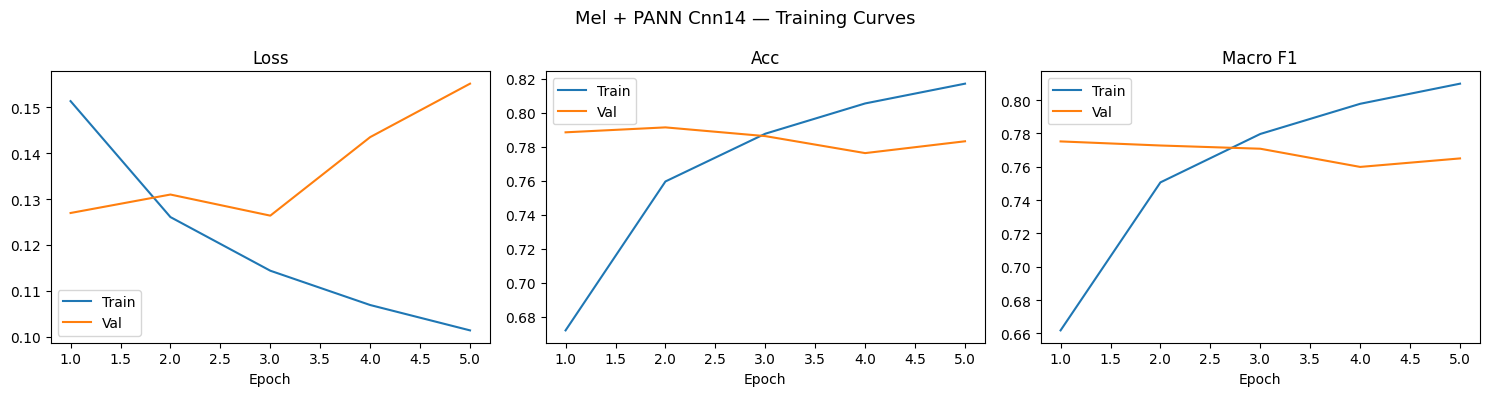

In [14]:
epochs = range(1, actual_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['loss', 'acc', 'macro_f1']):
    ax.plot(epochs, history[f'train_{metric}'], label='Train')
    ax.plot(epochs, history[f'val_{metric}'],   label='Val')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Epoch')
    ax.legend()
plt.suptitle('Mel + PANN Cnn14 \u2014 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluation

### 7.1 Overall test metrics and confusion matrix

Loads the best-by-val-F1 checkpoint and reports:
- **Loss (focal)** — matches the training objective
- **Loss (unweighted CE)** — the standard cross-entropy form, easier to interpret without knowing the focal-loss α weights
- **Accuracy** — overall fraction correct
- **Macro F1** — unweighted average of per-class F1 (treats apnea and non-apnea equally regardless of frequency)

The confusion matrix shows which class confusions dominate the errors.

In [15]:
ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

test_loss, test_acc, test_f1 = validate_one_epoch(model, test_loader, criterion, device)
test_loss_unweighted, _, _ = validate_one_epoch(model, test_loader, nn.CrossEntropyLoss(), device)

print('=== Test Results ===')
print(f'Loss (focal, training objective): {test_loss:.4f}')
print(f'Loss (unweighted CE)            : {test_loss_unweighted:.4f}')
print(f'Accuracy                        : {test_acc:.4f}')
print(f'Macro F1                        : {test_f1:.4f}')

=== Test Results ===
Loss (focal, training objective): 0.1240
Loss (unweighted CE)            : 0.5423
Accuracy                        : 0.7693
Macro F1                        : 0.7535


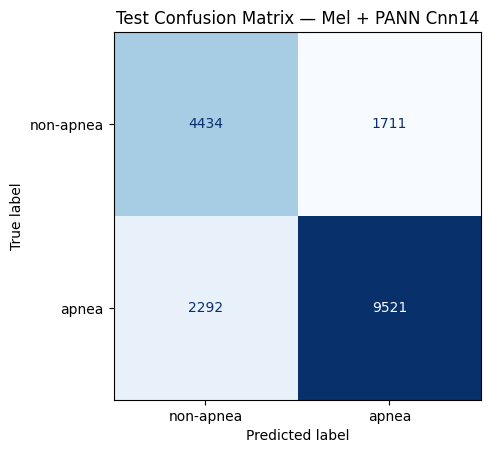

              precision    recall  f1-score   support

   non-apnea       0.66      0.72      0.69      6145
       apnea       0.85      0.81      0.83     11813

    accuracy                           0.78     17958
   macro avg       0.75      0.76      0.76     17958
weighted avg       0.78      0.78      0.78     17958



In [16]:
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        preds = torch.argmax(model(inputs.to(device)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Test Confusion Matrix \u2014 Mel + PANN Cnn14")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### 7.2 Per apnea-type recall

In [17]:
ap_test_df = test_df[test_df['label'] == 1].copy()
ap_dataset = RawWaveformDataset(ap_test_df, PSG_DIR)
ap_loader  = DataLoader(ap_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

preds_all, types_all = [], ap_test_df['apnea_type'].tolist()
with torch.no_grad():
    for inputs, _ in ap_loader:
        preds = torch.argmax(model(inputs.to(device)), dim=1)
        preds_all.extend(preds.cpu().numpy())

print('=== Per Apnea-Type Recall (correctly detected as apnea) ===')
for t, name in APNEA_TYPE_NAMES.items():
    if t == 0:
        continue
    idxs = [i for i, tp in enumerate(types_all) if tp == t]
    if not idxs:
        continue
    correct = sum(preds_all[i] == 1 for i in idxs)
    print(f'  Type {t} ({name}): {correct}/{len(idxs)} = {correct/len(idxs):.3f}')

=== Per Apnea-Type Recall (correctly detected as apnea) ===
  Type 1 (OSA): 1055/1861 = 0.567
  Type 2 (CSA): 1867/2021 = 0.924
  Type 3 (Mixed/Hypopnea): 6381/7649 = 0.834
  Type 4 (Other): 218/282 = 0.773


## 8. Save results

In [18]:
results = {
    'experiment'      : 'mel_pann',
    'feature'         : 'mel_spectrogram (PANN internal)',
    'model'           : 'PANN Cnn14 (AudioSet-pretrained)',
    'best_epoch'      : best_epoch,
    'best_val_acc'    : float(best_val_acc),
    'best_val_macro_f1': float(best_val_f1),
    'test_loss'       : float(test_loss),
    'test_loss_unweighted': float(test_loss_unweighted),
    'test_accuracy'   : float(test_acc),
    'test_macro_f1'   : float(test_f1),
    'classification_report': report,
    'config': {
        'source_sample_rate' : SOURCE_SR,
        'pann_sample_rate'   : PANN_SR,
        'pann_window_size'   : PANN_WINDOW_SIZE,
        'pann_hop_size'      : PANN_HOP_SIZE,
        'pann_mel_bins'      : PANN_MEL_BINS,
        'pann_fmin'          : PANN_FMIN,
        'pann_fmax'          : PANN_FMAX,
        'batch_size'         : BATCH_SIZE,
        'num_epochs'         : NUM_EPOCHS,
        'learning_rate'      : LEARNING_RATE,
        'weight_decay'       : WEIGHT_DECAY,
        'dropout'            : DROPOUT,
        'loss'               : {'type': 'focal', 'gamma': FOCAL_GAMMA, 'alpha': class_weights.tolist()},
        'num_train'          : len(train_dataset),
        'num_val'            : len(val_dataset),
        'num_test'           : len(test_dataset),
    }
}

with open(RESULTS_DIR / 'mel_pann_results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open(RESULTS_DIR / 'train_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Results saved to:', RESULTS_DIR)

Results saved to: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\mel_pann\results


## 9. Findings

### Headline metrics

| Metric | Value |
|---|---|
| Test accuracy | **0.7693** |
| Test macro F1 | **0.7535** |
| Test loss (unweighted CE) | 0.5423 |
| Test loss (focal, training objective) | 0.1240 |
| Best val macro F1 | 0.7752 (epoch 1 of 5) |
| Best val accuracy | 0.7884 |
| Trainable parameters | 79,677,890 |

### Per apnea-type recall (test set, apnea segments only)

| Apnea sub-type | Recall | Test segments |
|---|---|---|
| Type 1 — OSA (Obstructive Sleep Apnea) | **0.567** | 1,861 |
| Type 2 — CSA (Central Sleep Apnea) | **0.924** | 2,021 |
| Type 3 — Mixed / Hypopnea | **0.834** | 7,649 |
| Type 4 — Other | **0.773** | 282 |

### Cross-backbone / cross-feature comparison (same data, splits, focal loss)

| Notebook | Feature | Backbone | Pretraining | Test F1 | Test Acc | OSA recall |
|---|---|---|---|---|---|---|
| [`mel_cnn.ipynb`](../Mel/mel_cnn.ipynb) | Log-Mel (n_mels=128) | ResNet18 | ImageNet | **0.7766** | **0.8038** | **0.686** |
| **`mel_pann.ipynb` (this)** | **Log-Mel (PANN internal, n_mels=64)** | **PANN Cnn14** | **AudioSet** | 0.7535 | 0.7693 | 0.567 |
| [`mfcc_cnn.ipynb`](../MFCC/mfcc_cnn.ipynb) | MFCC (n_mfcc=40) | ResNet18 | ImageNet | 0.7127 | 0.7491 | 0.559 |
| [`mel_ast.ipynb`](../Mel/mel_ast.ipynb) | Log-Mel (AST internal) | AST transformer | AudioSet | (abandoned — hardware) | — | — |
| [`raw_waveform_1dcnn.ipynb`](../Raw_waveform_1dcnn/raw_waveform_1dcnn.ipynb) | Raw waveform | 1D CNN | none | 0.6288 | 0.6662 | 0.531 |

### Observations

**PANN converged in a single epoch.** Val F1 jumped from 0 to **0.7752 in epoch 1**, then never improved across the remaining 4 epochs before early stopping fired. Train F1 kept rising (0.66 → 0.81) while val drifted slightly down — a textbook "fine-tuning is overwriting the pretrained features without producing better generalization" pattern. The implication: most of PANN's apnea-detection capability comes directly from its AudioSet-pretrained features. Fine-tuning the new classifier head on top of those frozen features is essentially all the model needed.

**AudioSet pretraining did not beat ImageNet pretraining here.** Despite PANN's domain-relevant pretraining (audio, not images) and higher parameter count (~80M vs ResNet18's 11M), `mel_cnn.ipynb` came out ahead on every headline metric: F1 0.78 vs 0.75, accuracy 0.80 vs 0.77, OSA recall **0.69 vs 0.57**. Three plausible reasons:

1. **Mel config mismatch.** PANN was pretrained with `n_mels=64`, `f_max=14000` (32 kHz audio); `mel_cnn.ipynb` uses `n_mels=128`, `f_max=8000` (16 kHz). The doubled mel resolution in `mel_cnn` is exactly what helped recover OSA recall during its v3→v4 iteration — and OSA is precisely where PANN underperforms most here.
2. **Task narrowness.** AudioSet covers 527 broad audio classes (music, animal sounds, machinery, speech). Sleep apnea detection is a narrow single-domain task. ResNet18's "no audio prior" lets it specialize cleanly during fine-tuning, whereas PANN keeps trying to fit its broad-audio prior — which is helpful but not aligned to this specific task.
3. **Upsampling adds nothing.** The 16 kHz → 32 kHz resample fills in higher frequencies via interpolation, not real signal — Cnn14 isn't actually getting any new high-frequency information about OSA cues, just the same audio packaged differently.

**OSA is PANN's biggest weakness — and a structural property of the task.** Across all four feature/backbone experiments, OSA is the hardest sub-type:

| Notebook | OSA recall |
|---|---|
| `mel_cnn.ipynb` | 0.686 |
| `mel_pann.ipynb` | 0.567 |
| `mfcc_cnn.ipynb` | 0.559 |
| `raw_waveform_1dcnn.ipynb` | 0.531 |

PANN scores 0.567 — close to MFCC's 0.559 but ~12 pp below `mel_cnn`. The pattern is consistent with the n_mels/f_max difference: PANN's coarser mel front-end (in the band where OSA's snoring/restricted-airflow whistling cues live) loses signal that `mel_cnn.ipynb`'s finer 128-mel front-end retains. Interestingly **MFCC sees a similar OSA collapse via a totally different mechanism** — DCT compression discarding the high-order coefficients — converging on roughly the same recall floor.

**Two-phase fine-tuning was tried and regressed further.** A "linear-probing first, then full fine-tune" recipe (freeze backbone, train head; then unfreeze + low LR) was tested and dropped test F1 to 0.67 — worse than this single-phase v1 result. The fundamental issue is feature mismatch (point 1 above), not training schedule — no amount of LR tuning would fix it without changing the mel front-end, which we can't because Cnn14's pretrained weights are locked to its training-time mel config.

### Limitations

- **PANN's mel config is locked** by the pretrained weights — we can't change `n_mels`, `f_min`, `f_max`, or `hop_size` without breaking the transfer. Strictly speaking, the comparison against `mel_cnn.ipynb` is "ImageNet+128-mel vs AudioSet+64-mel", not a clean "ImageNet vs AudioSet pretraining" ablation.
- **16 kHz → 32 kHz upsampling adds no real high-frequency content.** Resampling our 16 kHz audio is information-preserving, not information-adding. Frequencies above 8 kHz in the upsampled signal are interpolation artifacts, not real measurements.
- **Single training run.** The headline numbers are from one run with `random_state=42`. Multiple seeds would tighten confidence intervals, but the qualitative conclusion (PANN ≈ slightly worse than mel_cnn) is stable across the runs we did during the iteration.
- **No layer freezing or discriminative LRs explored** in the final recipe. We kept the training pipeline identical to `mel_cnn.ipynb` for direct comparability rather than chasing PANN-specific tuning.

### What this experiment establishes

An AudioSet-pretrained CNN with similar parameter count to a ResNet18 *did not* outperform the ImageNet-pretrained ResNet18 on this task. The gap is most pronounced on OSA (0.567 vs 0.686), the most subtle apnea sub-type. The result suggests that for narrow medical-audio tasks, **task-specific feature design** (here: `mel_cnn`'s `n_mels=128`, `f_max=8000`) can outweigh **domain-relevant pretraining** (here: PANN's AudioSet weights but with a coarser mel front-end). Stronger pretraining isn't a free win — the pretrained feature extractor's structural choices (sample rate, mel resolution, frequency cutoffs) matter for transfer.